In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import importlib
import model_functions
import utils
importlib.reload(model_functions)
importlib.reload(utils)

from utils import discount

from model_functions import load_transition_matrix, gen_risk_matrix, gen_transition_probabilities, run_markov_cohort, \
    run_mc_sim, calculate_outcomes, plot_trace, load_costs, STAGE_ORDER, run_comparison

In [96]:
# GLOBAL initial values
cycle_length = 1/4 # in years
starting_age = 15  # TODO change to 12?
n_years = 100 - starting_age  # simulate until age 100
n_cycles = int(n_years / cycle_length)

In [129]:
tm = load_transition_matrix('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv', "_obs", cycle_length=cycle_length)
rm = gen_risk_matrix(regression_risk=1.56, progression_risk=1)

initial_prevalence = [.628, 0.309, 0.035, 0.016, 0.012, 0,0,0,0,0]

trace = run_markov_cohort(tm, initial_prevalence, n_cycles, starting_age=starting_age, cycle_length=cycle_length)

trace_rm = run_markov_cohort(tm, initial_prevalence, n_cycles, starting_age=starting_age, cycle_length=cycle_length, risk_matrix=rm)


to_state          F0        F1        F2        F3        F4       HCC  \
from_state                                                               
F0          0.983544  0.016119  0.000000  0.000000  0.000000  0.000000   
F1          0.006231  0.976330  0.017102  0.000000  0.000000  0.000000   
F2          0.000000  0.011434  0.973833  0.014395  0.000000  0.000000   
F3          0.000000  0.000000  0.014888  0.972736  0.011187  0.000851   
F4          0.000000  0.000000  0.000000  0.011681  0.961496  0.009587   
HCC         0.000000  0.000000  0.000000  0.000000  0.000000  0.891436   
DC          0.000000  0.000000  0.000000  0.000000  0.000000  0.001738   
LT          0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
post-LT     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
Death       0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

to_state          DC        LT   post-LT     Death  
from_state                                          
F0   

In [91]:
outcomes = calculate_outcomes(trace, cycle_length, 'SOC')

print('\nIntervention added')
outcomes_rm = calculate_outcomes(trace_rm, cycle_length, 'Semaglutide')


Total LY:  43.51309823612231
Total QALY:  36.080872800547574
Total Cost:  803709.4496782159
Discounted LY:  23.20717262454948
Discounted QALY:  19.767460092453703
Discounted Cost:  377115.7705035754

Intervention added
Total LY:  44.97285301066377
Total QALY:  37.743090701805656
Total Cost:  1039959.4710283497
Discounted LY:  23.640195293263517
Discounted QALY:  20.307236022317742
Discounted Cost:  510630.52530965663


In [121]:
outcomes = calculate_outcomes(trace, cycle_length, 'SOC')

print('\nIntervention added')
outcomes_rm = calculate_outcomes(trace_rm, cycle_length, 'Semaglutide')


Total LY:  43.51309823612231
Total QALY:  36.080872800547574
Total Cost:  803709.4496782159
Discounted LY:  23.20717262454948
Discounted QALY:  19.767460092453703
Discounted Cost:  377115.7705035754

Intervention added
Total LY:  44.10505773018184
Total QALY:  36.790257943483134
Total Cost:  1070835.0363522745
Discounted LY:  23.374514138192367
Discounted QALY:  19.989415960880393
Discounted Cost:  524078.97007178696


In [82]:
(510630 - 377115) / (20.30723 - 19.767)

247144.73465005597

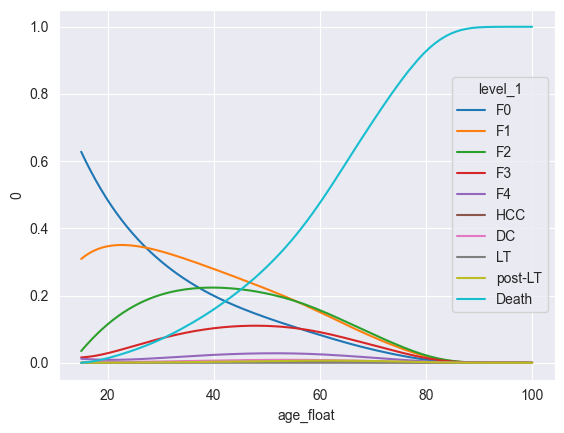

In [122]:

plot_trace(trace)

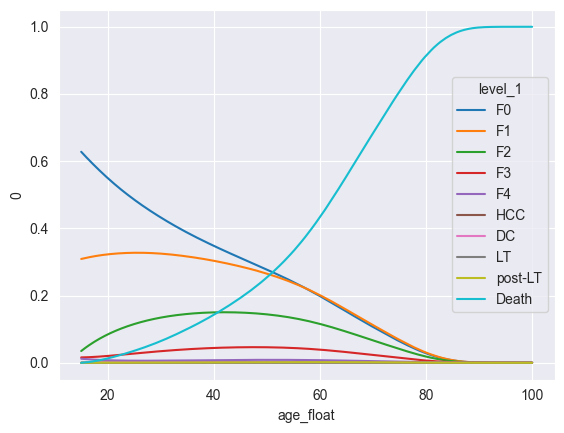

In [94]:

plot_trace(trace_rm)

# Test main comparison

Running model for treatment: SOC
Total LY:  43.51309823612231
Total QALY:  36.080872800547574
Total Cost:  803709.4496782159
Discounted LY:  23.20717262454948
Discounted QALY:  19.767460092453703
Discounted Cost:  377115.7705035754
Running model for treatment: Semaglutide
Total LY:  45.30212615727557
Total QALY:  38.15211725569796
Total Cost:  1026796.8530045697
Discounted LY:  23.744519454326536
Discounted QALY:  20.447946236491912
Discounted Cost:  505002.11325894983


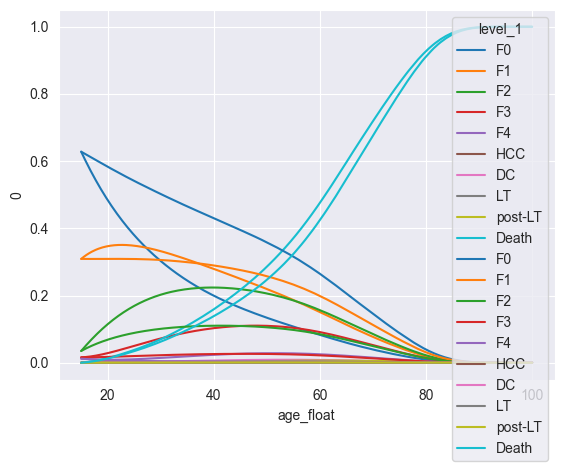

In [137]:
results, traces = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=[1, 1.56], pr=[1, 1/1.56], 
               n_cycles=n_cycles, starting_age=starting_age,
                     cycle_length=cycle_length, discount_rate = 0.03)

,QALY,Cost,Delta_Cost,Delta_QALY,ICER
SOC,19.767460,377115.770504,377115.770504,19.767460,19077.603736
Semaglutide,20.447946,505002.113259,127886.342755,0.680486,187933.793915


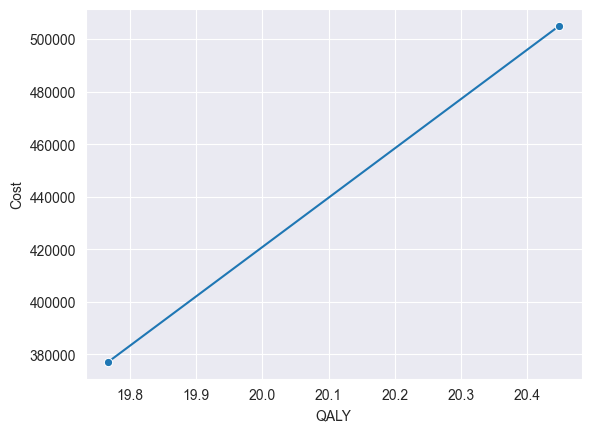

In [138]:
from utils import plot_cea

plot_cea(cea_dict=results)

# Explore Efficacy Approaches